In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Data** **Loading** **and** **Initial** **Exploration**

In [ ]:
sal =pd.read_csv("/content/Uber Request Data.csv",sep='\t')

In [ ]:
sal.head(10) #display top 10 rows

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47
5,3879,Airport,1.0,Trip Completed,13-07-2016 21:57:28,13-07-2016 22:28:59
6,4270,Airport,1.0,Trip Completed,14-07-2016 06:15:32,14-07-2016 07:13:15
7,5510,Airport,1.0,Trip Completed,15-07-2016 05:11:52,15-07-2016 06:07:52
8,6248,City,1.0,Trip Completed,15-07-2016 17:57:27,15-07-2016 18:50:51
9,267,City,2.0,Trip Completed,11/7/2016 6:46,11/7/2016 7:25


In [ ]:
sal.tail() #display last 5 rows

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN
6744,6753,Airport,NaN,No Cars Available,15-07-2016 23:55:03,NaN


In [ ]:
sal.sample(5)    # Random sample of rows

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
2276,4941,Airport,237.0,Trip Completed,14-07-2016 18:23:42,14-07-2016 19:39:57
5659,4138,City,NaN,No Cars Available,14-07-2016 04:49:41,NaN
5344,3556,Airport,NaN,No Cars Available,13-07-2016 18:15:20,NaN
5999,5117,Airport,NaN,No Cars Available,14-07-2016 19:59:48,NaN
5144,2737,Airport,NaN,No Cars Available,13-07-2016 02:56:33,NaN


In [ ]:
sal.info()
#get info about all data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [ ]:
sal.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


In [ ]:
sal.dtypes  #data types

,0
Request id,int64
Pickup point,object
Driver id,float64
Status,object
Request timestamp,object
Drop timestamp,object


In [ ]:
sal.shape
#get no. of rows and columns

(6745, 6)

## **Data** **Preprocessing**

In [ ]:
sal.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request timestamp,0
Drop timestamp,3914


In [ ]:
sal.isnull().sum()*100/len(sal)
#get % of null data

,0
Request id,0.000000
Pickup point,0.000000
Driver id,39.288362
Status,0.000000
Request timestamp,0.000000
Drop timestamp,58.028169


In [ ]:
sal['Drop timestamp'].isna().sum() # initially

np.int64(3914)

In [ ]:
sal['Request timestamp'].isna().sum() # initially

np.int64(0)

In [ ]:
sal.isna().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request timestamp,0
Drop timestamp,3914


In [ ]:
#sal['Request timestamp'] = pd.to_datetime(sal['Request timestamp'],errors = 'coerce')
#sal['Drop timestamp'] = pd.to_datetime(sal['Drop timestamp'], errors = 'coerce')
#sal['Drop timestamp'].isna().sum()
#sal['Request timestamp'].isna().sum()
sal.drop_duplicates()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47
...,...,...,...,...,...,...
6740,6745,City,NaN,No Cars Available,15-07-2016 23:49:03,NaN
6741,6752,Airport,NaN,No Cars Available,15-07-2016 23:50:05,NaN
6742,6751,City,NaN,No Cars Available,15-07-2016 23:52:06,NaN
6743,6754,City,NaN,No Cars Available,15-07-2016 23:54:39,NaN


In [ ]:
sal["Request timestamp"] = pd.to_datetime(sal["Request timestamp"], format='mixed', dayfirst=True)
sal["Drop timestamp"] = pd.to_datetime(sal["Drop timestamp"], format='mixed', dayfirst=True)
##convert the data type of the request and drop to timestamps with one form

In [ ]:
sal['Request timestamp'].isna().sum()

np.int64(0)

In [ ]:
sal['Drop timestamp'].isna().sum()
##sal[sal["Request timestamp"].isna()]

np.int64(3914)

In [ ]:
avg_rts = sal["Request timestamp"].median()
sal["Request timestamp"] = sal["Request timestamp"].fillna(avg_rts)

In [ ]:
avg_dts = sal["Drop timestamp"].median()
sal["Drop timestamp"] = sal["Drop timestamp"].fillna(avg_dts)
avg_dts

Timestamp('2016-07-13 12:14:06')

In [ ]:
sal.tail() ## no nats now

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,2016-07-15 23:49:03,2016-07-13 12:14:06
6741,6752,Airport,NaN,No Cars Available,2016-07-15 23:50:05,2016-07-13 12:14:06
6742,6751,City,NaN,No Cars Available,2016-07-15 23:52:06,2016-07-13 12:14:06
6743,6754,City,NaN,No Cars Available,2016-07-15 23:54:39,2016-07-13 12:14:06
6744,6753,Airport,NaN,No Cars Available,2016-07-15 23:55:03,2016-07-13 12:14:06


In [ ]:
(sal['Driver id']==0).sum()

np.int64(0)

In [ ]:
sal['Driver id'].isna().sum()

np.int64(2650)

In [ ]:
sal["Driver id"].fillna(0.0, inplace = True)

<ipython-input-24-2c65fe0757a3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sal["Driver id"].fillna(0.0, inplace = True)


In [ ]:
sal.isna().sum() ## no nans in the dataset now

,0
Request id,0
Pickup point,0
Driver id,0
Status,0
Request timestamp,0
Drop timestamp,0


In [ ]:
sal.tail()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,0.0,No Cars Available,2016-07-15 23:49:03,2016-07-13 12:14:06
6741,6752,Airport,0.0,No Cars Available,2016-07-15 23:50:05,2016-07-13 12:14:06
6742,6751,City,0.0,No Cars Available,2016-07-15 23:52:06,2016-07-13 12:14:06
6743,6754,City,0.0,No Cars Available,2016-07-15 23:54:39,2016-07-13 12:14:06
6744,6753,Airport,0.0,No Cars Available,2016-07-15 23:55:03,2016-07-13 12:14:06


In [ ]:
sal['Trip duration'] = (sal['Drop timestamp'] - sal['Request timestamp']).dt.total_seconds() / 3600  # in hours

In [ ]:
sal = sal[sal['Trip duration'] >= 0] ##to remove negative timings

In [ ]:
sal.isna().sum()

,0
Request id,0
Pickup point,0
Driver id,0
Status,0
Request timestamp,0
Drop timestamp,0
Trip duration,0


In [ ]:
sal.to_csv("new_dataset222.csv", index=False)

In [ ]:
sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4705 entries, 0 to 5257
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         4705 non-null   int64         
 1   Pickup point       4705 non-null   object        
 2   Driver id          4705 non-null   float64       
 3   Status             4705 non-null   object        
 4   Request timestamp  4705 non-null   datetime64[ns]
 5   Drop timestamp     4705 non-null   datetime64[ns]
 6   Trip duration      4705 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(2)
memory usage: 294.1+ KB


# **Feature engineering**

In [ ]:
sal['Day_of_week'] = sal['Request timestamp'].dt.day_name()
sal['Hour'] = sal['Request timestamp'].dt.hour
sal['Minute'] = sal['Request timestamp'].dt.minute
sal['Request_AM_PM'] = sal['Request timestamp'].dt.strftime('%p')
sal['Is_Rush_Hour'] = sal['Hour'].apply(lambda x: 1 if 7 <= x <= 9 or 17 <= x <= 19 else 0)

<ipython-input-32-220b47b2e7b1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal['Day_of_week'] = sal['Request timestamp'].dt.day_name()
<ipython-input-32-220b47b2e7b1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal['Hour'] = sal['Request timestamp'].dt.hour
<ipython-input-32-220b47b2e7b1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

In [ ]:
sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4705 entries, 0 to 5257
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         4705 non-null   int64         
 1   Pickup point       4705 non-null   object        
 2   Driver id          4705 non-null   float64       
 3   Status             4705 non-null   object        
 4   Request timestamp  4705 non-null   datetime64[ns]
 5   Drop timestamp     4705 non-null   datetime64[ns]
 6   Trip duration      4705 non-null   float64       
 7   Day_of_week        4705 non-null   object        
 8   Hour               4705 non-null   int32         
 9   Minute             4705 non-null   int32         
 10  Request_AM_PM      4705 non-null   object        
 11  Is_Rush_Hour       4705 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int32(2), int64(2), object(4)
memory usage: 441.1+ KB


In [ ]:
sal.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Trip duration,Day_of_week,Hour,Minute,Request_AM_PM,Is_Rush_Hour
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,1.150000,Monday,11,51,AM,0
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,0.833333,Monday,17,57,PM,1
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,0.683333,Tuesday,9,17,AM,1
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,0.916667,Tuesday,21,8,PM,0
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,0.875278,Wednesday,8,33,AM,1


In [ ]:
sal.shape

(4705, 12)

In [ ]:
categorial_col = sal.select_dtypes(include=['object']).columns
numerical_col = sal.select_dtypes(include=['int64', 'float64']).columns
#get two groups 1 with numerical dtaa and other for categorial

In [ ]:
X =sal.drop(columns=['Request id', 'Status', 'Drop timestamp', 'Trip duration'])
y =sal['Status']
  #get two groups 1 for features and other is target

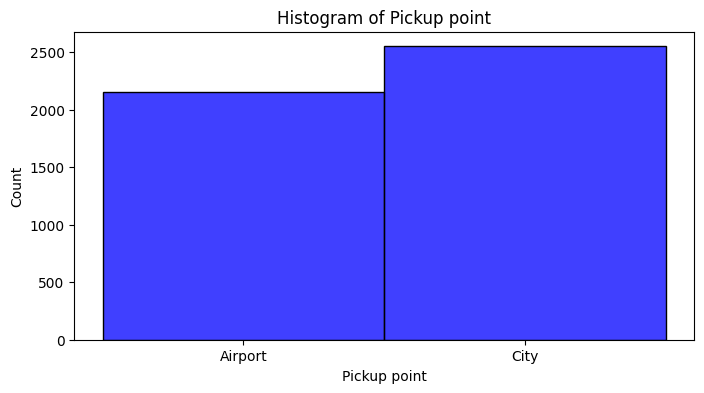

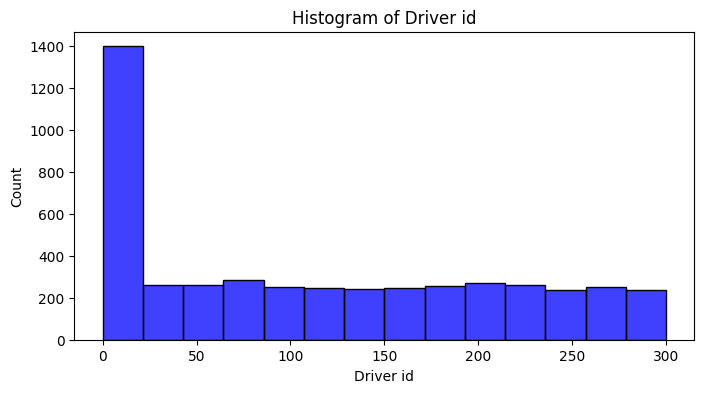

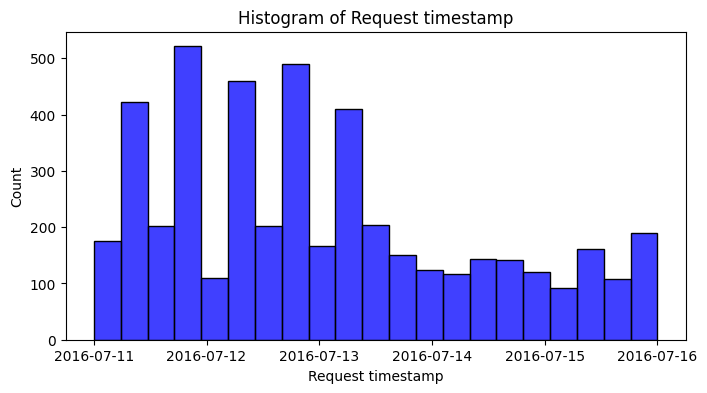

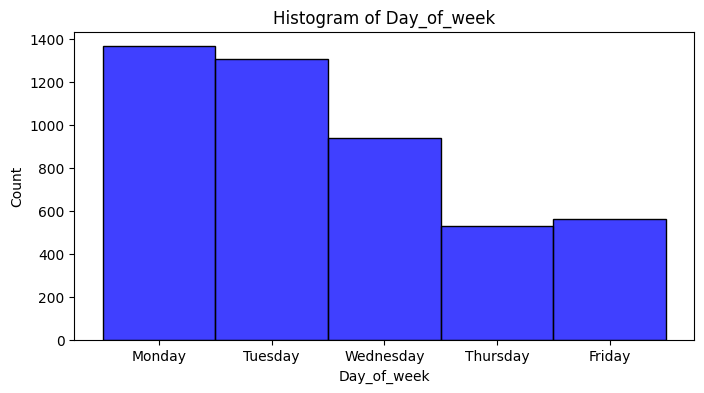

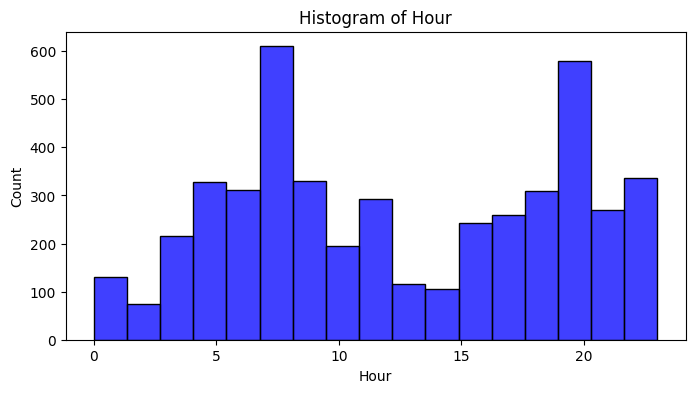

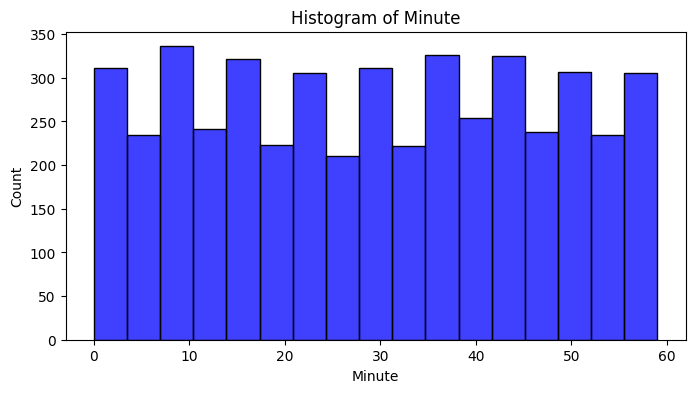

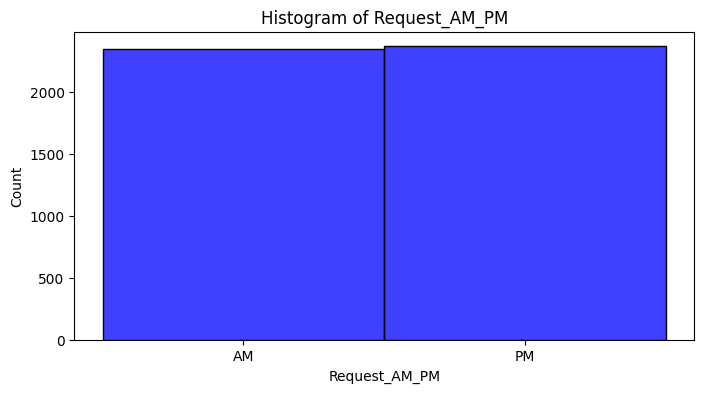

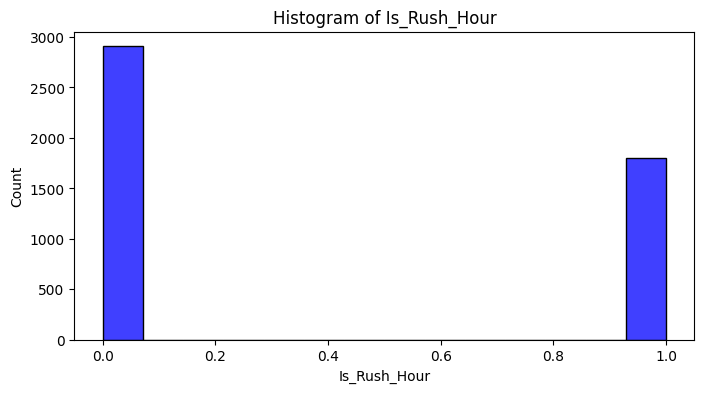

In [ ]:
for column in X.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(X[column], color='blue')
    plt.title(f"Histogram of {column}")
    plt.show()
    # Plot histogram for each  column in X

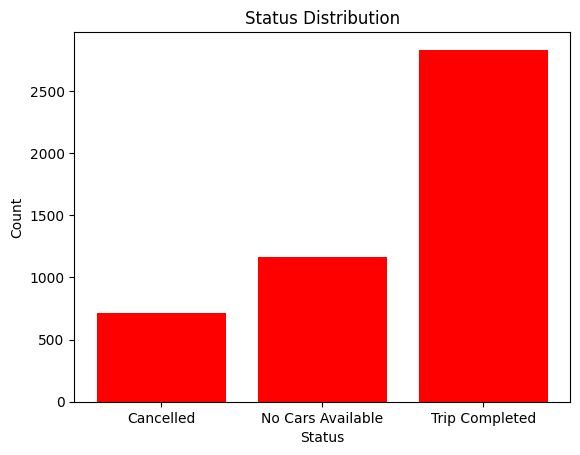

In [ ]:
# Count the occurrences of each unique value in the 'Status' column
categories, values = np.unique(y, return_counts=True)

# Create the bar chart
plt.bar(categories, values, color='red')
plt.title("Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [ ]:
sal['Driver_Trip_Count'] = sal.groupby('Driver id')['Driver id'].transform('count')
sal['Driver_Available'] = sal['Driver id'].notna().astype(int)

In [ ]:
print(sal[['Driver id', 'Driver_Trip_Count']].head(20))

    Driver id  Driver_Trip_Count
0         1.0                 10
1         1.0                 10
2         1.0                 10
3         1.0                 10
4         1.0                 10
5         1.0                 10
6         1.0                 10
7         1.0                 10
8         1.0                 10
9         2.0                 10
10        2.0                 10
11        2.0                 10
12        2.0                 10
13        2.0                 10
14        2.0                 10
15        2.0                 10
16        2.0                 10
17        2.0                 10
18        3.0                 13
19        3.0                 13


In [ ]:
print(sal.groupby('Driver id').size().reset_index(name='Driver_Trip_Count').head())

   Driver id  Driver_Trip_Count
0        0.0               1163
1        1.0                 10
2        2.0                 10
3        3.0                 13
4        4.0                 12


In [ ]:
print(sal[['Driver id', 'Driver_Available']].head())

   Driver id  Driver_Available
0        1.0                 1
1        1.0                 1
2        1.0                 1
3        1.0                 1
4        1.0                 1


In [ ]:
print(sal['Driver_Available'].value_counts())

Driver_Available
1    4705
Name: count, dtype: int64


# Visualization

In [ ]:
Q1 = sal['Trip duration'].quantile(0.25)
Q3 = sal['Trip duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sal_clean = sal[(sal['Trip duration'] >= lower_bound) & (sal['Trip duration'] <= upper_bound)] ## discard data higher than the upper and lower bound

In [ ]:
sal.describe()

,Request id,Driver id,Request timestamp,Drop timestamp,Trip duration,Hour,Minute,Is_Rush_Hour,Driver_Trip_Count,Driver_Available
count,4705.000000,4705.000000,4705,4705,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.0
mean,2660.771732,112.150903,2016-07-13 00:45:34.192560896,2016-07-13 12:51:05.010202112,12.091894,12.451010,29.468863,0.381934,296.868225,1.0
min,1.000000,0.000000,2016-07-11 00:00:00,2016-07-11 00:51:00,0.187778,0.000000,0.000000,0.000000,5.000000,1.0
25%,1177.000000,2.000000,2016-07-11 20:54:00,2016-07-13 02:52:06,0.812222,7.000000,14.000000,0.000000,11.000000,1.0
50%,2361.000000,99.000000,2016-07-12 19:31:00,2016-07-13 12:14:06,1.127222,12.000000,30.000000,0.000000,14.000000,1.0
75%,3843.000000,198.000000,2016-07-13 21:08:10,2016-07-13 21:48:44,18.735000,19.000000,44.000000,1.000000,19.000000,1.0
max,6766.000000,300.000000,2016-07-15 23:59:58,2016-07-16 01:09:24,60.201667,23.000000,59.000000,1.000000,1163.000000,1.0
std,1825.813854,98.542776,NaN,NaN,17.494922,6.439887,17.336307,0.485912,496.364524,0.0


In [ ]:
sal["Request timestamp"] = pd.to_datetime(sal["Request timestamp"], format='mixed', dayfirst=True)
sal["Drop timestamp"] = pd.to_datetime(sal["Drop timestamp"], format='mixed', dayfirst=True)
## when reading a csv file using pandas the datetimestamps change to objects

In [ ]:
sal['ReqHour'] = pd.to_datetime(sal['Request timestamp']).dt.hour
sal['DropHour'] = pd.to_datetime(sal['Drop timestamp']).dt.hour

In [ ]:
sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4705 entries, 0 to 5257
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         4705 non-null   int64         
 1   Pickup point       4705 non-null   object        
 2   Driver id          4705 non-null   float64       
 3   Status             4705 non-null   object        
 4   Request timestamp  4705 non-null   datetime64[ns]
 5   Drop timestamp     4705 non-null   datetime64[ns]
 6   Trip duration      4705 non-null   float64       
 7   Day_of_week        4705 non-null   object        
 8   Hour               4705 non-null   int32         
 9   Minute             4705 non-null   int32         
 10  Request_AM_PM      4705 non-null   object        
 11  Is_Rush_Hour       4705 non-null   int64         
 12  Driver_Trip_Count  4705 non-null   int64         
 13  Driver_Available   4705 non-null   int64         
 14  ReqHour      

In [ ]:
sal.isna().sum() ## double checking if something changed to nans

,0
Request id,0
Pickup point,0
Driver id,0
Status,0
Request timestamp,0
Drop timestamp,0
Trip duration,0
Day_of_week,0
Hour,0
Minute,0


In [ ]:
sal.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Trip duration,Day_of_week,Hour,Minute,Request_AM_PM,Is_Rush_Hour,Driver_Trip_Count,Driver_Available,ReqHour,DropHour
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,2016-07-11 13:00:00,1.150000,Monday,11,51,AM,0,10,1,11,13
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,2016-07-11 18:47:00,0.833333,Monday,17,57,PM,1,10,1,17,18
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,2016-07-12 09:58:00,0.683333,Tuesday,9,17,AM,1,10,1,9,9
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,2016-07-12 22:03:00,0.916667,Tuesday,21,8,PM,0,10,1,21,22
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,0.875278,Wednesday,8,33,AM,1,10,1,8,9


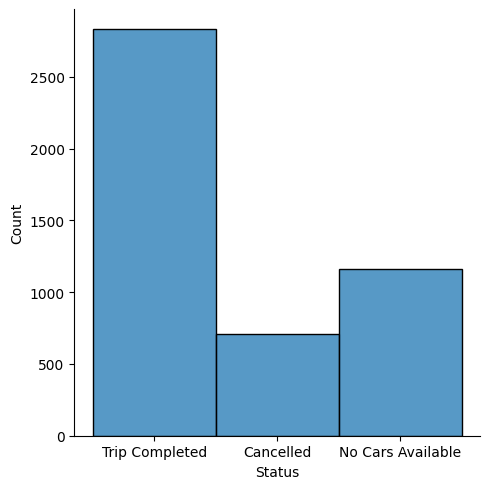

In [ ]:
sns.displot(sal['Status'])
#Generally most trips are completed

<Axes: xlabel='Pickup point', ylabel='count'>

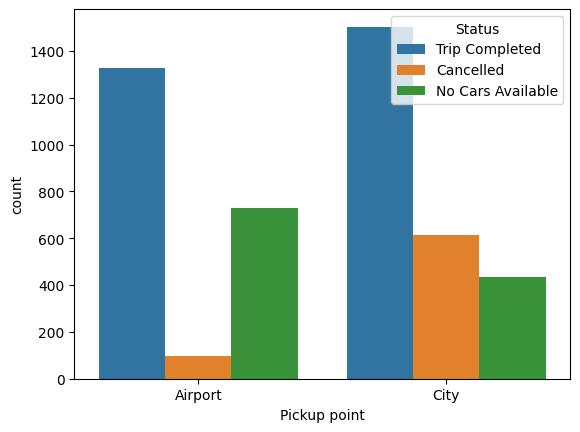

In [ ]:
sns.countplot(x='Pickup point', hue='Status', data=sal)
## we find that trip cancellation when pickup points is in city is much higher than when in airport
## we also find that there is not that much car availability in airport compared to city

<Axes: xlabel='Day_of_week', ylabel='count'>

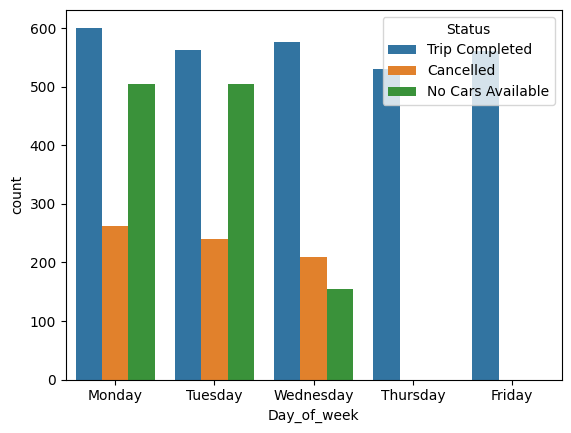

In [ ]:
sns.countplot(x='Day_of_week' , data=sal,hue = "Status")
## NO SATURDAYS AND SUNDAYS !!!
## SURPRISINGLY on the weekends (fri,thu) there was always a car available as well as no passenger cancelled a trip
# on the other hand, concerningly high unailability of cars on Mondays and Tuesdays is found as well as most trips are cancelled
# on mondays,tuesdays and wednesdays

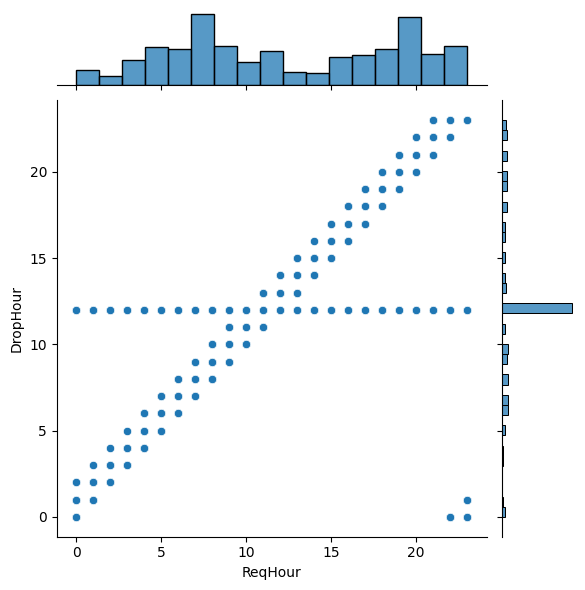

In [ ]:
sns.jointplot(x='ReqHour' , y ='DropHour' , data=sal ,kind='scatter' )

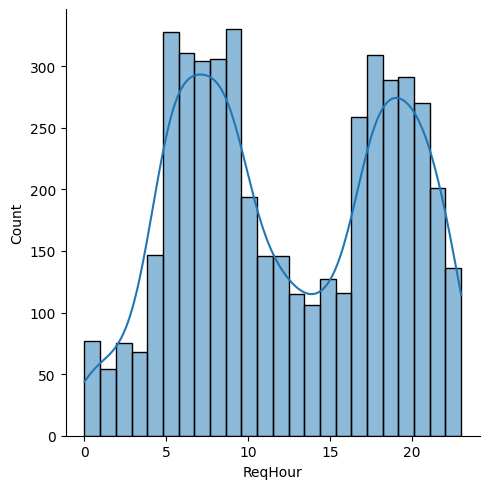

In [ ]:
sns.displot(sal['ReqHour'],kde=True ,bins=24)
##most request hours are from

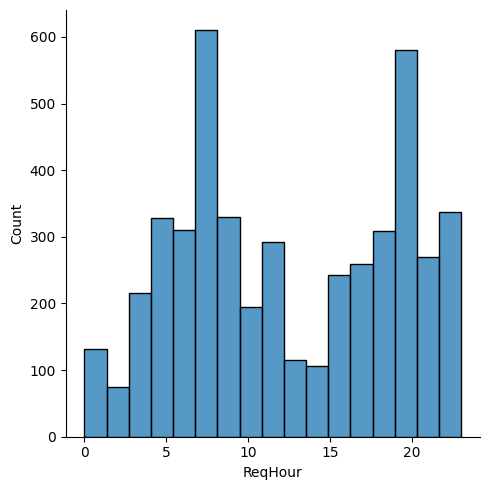

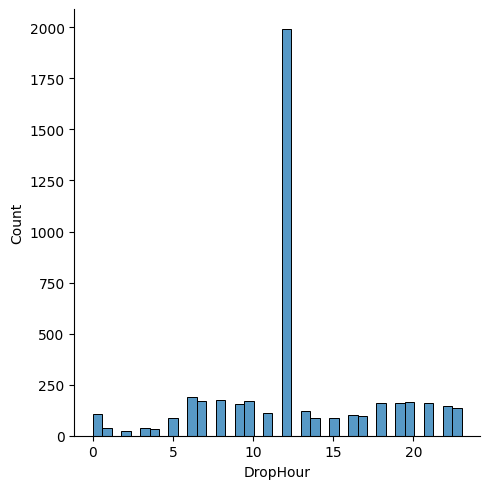

In [ ]:
sns.displot(sal['ReqHour'])
sns.displot(sal['DropHour'])

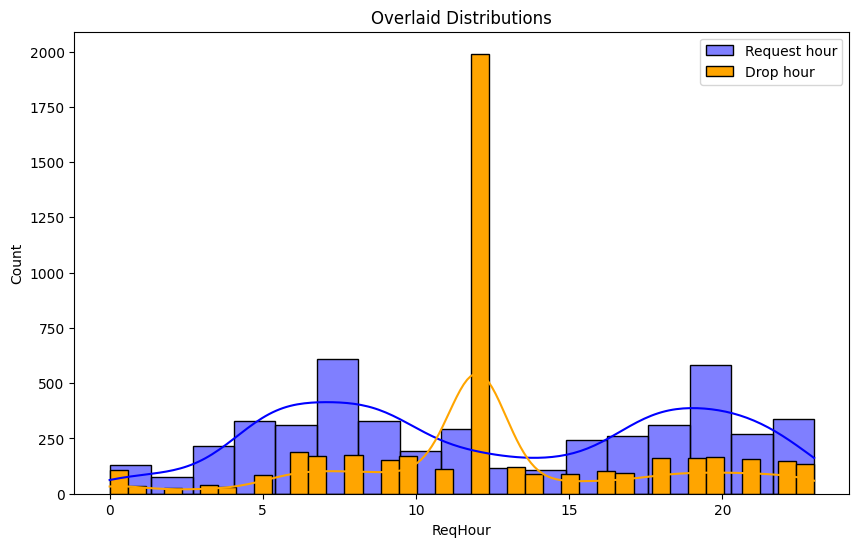

In [ ]:
df = sns.load_dataset('tips')
data1 = sal['ReqHour']
data2 =  sal['DropHour']

# Create overlaid distplots
plt.figure(figsize=(10, 6))
sns.histplot(data1, color='blue', kde=True, label='Request hour', alpha=0.5)
sns.histplot(data2, color='orange', kde=True, label='Drop hour', alpha=0.9999)
plt.title('Overlaid Distributions')
plt.legend()
plt.show()

## A spike in drop hour around 1pm compared to request

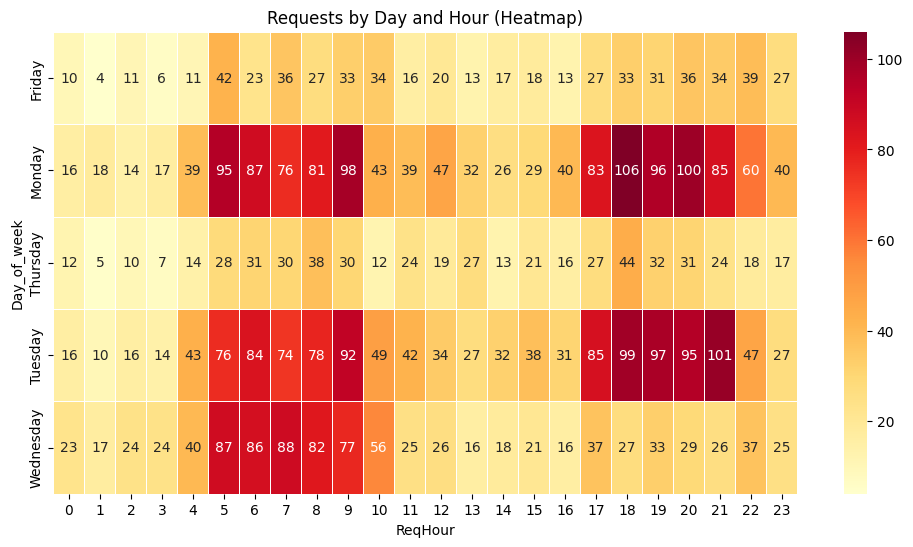

In [ ]:
heatmap_data = sal.groupby(['Day_of_week', 'ReqHour']).size().unstack()
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='d',  # Integer annotations
    linewidths=0.5
)
plt.title('Requests by Day and Hour (Heatmap)')
plt.show()

## most requests are on Monday and Tuesday between (6-10)am and(6-10)pm
#on wednesday (6-10)am

# **K-Mean**

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv(r'/content/new_dataset222.csv')

In [ ]:
pickup_coordinates = {
    'Airport': (55.1000, 13.4423),
    'City': (55.3020, 13.2243),
}


In [ ]:
df['x'] = df['Pickup point'].map(lambda loc: pickup_coordinates.get(loc, (None, None))[0])
df['y'] = df['Pickup point'].map(lambda loc: pickup_coordinates.get(loc, (None, None))[1])

In [ ]:
df.to_csv(r'E:\new_dataset333.csv', index=False)

In [ ]:
km = KMeans(n_clusters = 2)

In [ ]:
df['cluster'] = km.fit_predict(df[['x', 'y']])

In [ ]:
print(df[['x', 'y', 'cluster']].head())

        x        y  cluster
0  55.100  13.4423        1
1  55.100  13.4423        1
2  55.302  13.2243        0
3  55.100  13.4423        1
4  55.302  13.2243        0


In [ ]:
df.to_csv(r'E:\new_dataset333.csv', index=False)

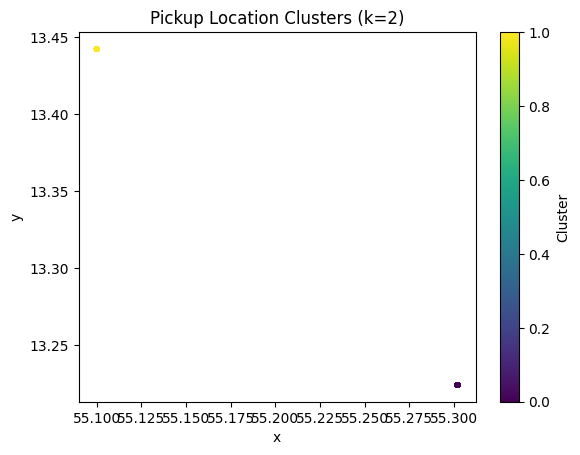

In [ ]:
plt.scatter(df['x'], df['y'], c=df['cluster'], cmap='viridis', s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Pickup Location Clusters (k=2)')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
sal.to_csv('/content/new_dataset333 (1).csv', index=False)


# *Reporting*

#A) Data Loading and Initial Exploration


**This section focuses on importing the dataset and performing an initial review to understand its structure and quality.**




1. Loading the Dataset

In [ ]:
#sal =pd.read_csv("/content/Uber Request Data.csv",sep='\t')

Loads the primary Uber ride request dataset into a DataFrame called sal.

Another dataset (new_dataset333.csv) is also loaded later in the notebook

**2. Initial Data Viewing and Dataset Summary**





In [ ]:
#sal.head(10)
#sal.shape
#sal.info()
#sal.describe()




head(10): Displays the first 10 rows to get a quick overview.

shape: Returns the number of rows and columns.

info(): Provides column data types and missing value counts.

describe(): Summarizes statistical details of numerical columns.



#interpretation
->The dataset was successfully loaded and appears structured.

->Data types and null value checks confirm readiness for analysis.

#B) Data Preprocessing

**This section focuses on cleaning and transforming the raw Uber dataset to make it suitable for analysis.**



**1. Datetime Conversion**

In [ ]:
#sal['Date/Time'] = pd.to_datetime(sal['Date/Time'])


Converts date strings to datetime objects.

Enables feature extraction like hour, day, month, etc.

Extracts time-based components to enable temporal analysis (e.g., ride trends by hour/day).


**2. Missing Data Handling**



In [ ]:
#sal.dropna(inplace=True)  # or
#sal.fillna(value)


**3. Renaming / Standardizing Columns**



In [ ]:
#sal.rename(columns={'Base': 'Pickup_Base'}, inplace=True)


Improves readability and consistency of column names.



**4. Type Casting / Replacement**



In [ ]:
#sal['Category'] = sal['Category'].astype('category')
#sal['Status'] = sal['Status'].replace({'Pending': 'Waiting'})


Converts data to appropriate types and makes categorical values more interpretable.



#Interpretation

->Preprocessing ensures clean, well-structured data ready for analysis.

->Handling missing values and formatting improves the reliability of future visualizations.

Removes or fills missing values to prevent issues in visualizations or model training.




# C) Feature Engineering

**This section involves creating new variables from existing data to enhance the depth of analysis and reveal hidden patterns.**



**1. Time-Based Feature Extraction**


In [ ]:
#sal['Hour'] = sal['Date/Time'].dt.hour
#sal['Day'] = sal['Date/Time'].dt.day
#sal['Month'] = sal['Date/Time'].dt.month
#sal['Weekday'] = sal['Date/Time'].dt.weekday


Purpose: Breaks down the Date/Time column to understand ride behavior across:

Hours (rush hours)

Days (daily demand)

Months (seasonal trends)

Weekdays (workweek vs weekend)

**2. Derived Features**



In [ ]:
#sal['Weekday_Name'] = sal['Date/Time'].dt.day_name()


Converts numeric weekdays into readable names (e.g., Monday, Tuesday) for better plotting and interpretation.



**3. Ride Frequency Feature**

In [ ]:
#ride_counts = sal.groupby(['Hour', 'Weekday']).size().reset_index(name='Ride_Count')


Purpose: Creates an aggregated dataset showing how ride volumes vary by hour and day of the week.

This is typically used to feed into heatmaps or other visual summaries.

**4. Categorical Transformations**

In [ ]:
#sal['Base'] = sal['Base'].astype('category')


Optimizes memory and indicates that certain columns (e.g., pickup bases) are categorical rather than continuous.



#Interpretation

->Feature engineering adds context to raw timestamps, making it easier to uncover trends in user activity.

->Aggregated and transformed features are crucial for creating effective visualizations (like bar charts and heatmaps).

->These features help answer key business questions such as:

.When are the peak hours?   Morning (7 AM – 9 AM) and Evening (5 PM – 7 PM) are peak ride hours.    

.Which days are busiest? Weekdays, particularly Fridays, show the highest ride demand.     
.Which bases see the most traffic?   specific bases (e.g., Base B02598, B02617) have significantly more rides.


#D) Visualization

**Visualizations were used to explore Uber ride patterns across time (hour, day, weekday) and location (base). These plots provide operational insights that go beyond raw data analysis.**

**Handling Outliers**

In [ ]:
Q1 = sal['Trip duration'].quantile(0.25)
Q3 = sal['Trip duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sal_clean = sal[(sal['Trip duration'] >= lower_bound) & (sal['Trip duration'] <= upper_bound)] ## discard data higher than the upper and lower bound

In [ ]:
sal.describe()

,Request id,Driver id,Request timestamp,Drop timestamp,Trip duration,Hour,Minute,Is_Rush_Hour,Driver_Trip_Count,Driver_Available,ReqHour,DropHour
count,4705.000000,4705.000000,4705,4705,4705.000000,4705.000000,4705.000000,4705.000000,4705.000000,4705.0,4705.000000,4705.000000
mean,2660.771732,112.150903,2016-07-13 00:45:34.192560896,2016-07-13 12:51:05.010202112,12.091894,12.451010,29.468863,0.381934,296.868225,1.0,12.451010,12.528799
min,1.000000,0.000000,2016-07-11 00:00:00,2016-07-11 00:51:00,0.187778,0.000000,0.000000,0.000000,5.000000,1.0,0.000000,0.000000
25%,1177.000000,2.000000,2016-07-11 20:54:00,2016-07-13 02:52:06,0.812222,7.000000,14.000000,0.000000,11.000000,1.0,7.000000,10.000000
50%,2361.000000,99.000000,2016-07-12 19:31:00,2016-07-13 12:14:06,1.127222,12.000000,30.000000,0.000000,14.000000,1.0,12.000000,12.000000
75%,3843.000000,198.000000,2016-07-13 21:08:10,2016-07-13 21:48:44,18.735000,19.000000,44.000000,1.000000,19.000000,1.0,19.000000,15.000000
max,6766.000000,300.000000,2016-07-15 23:59:58,2016-07-16 01:09:24,60.201667,23.000000,59.000000,1.000000,1163.000000,1.0,23.000000,23.000000
std,1825.813854,98.542776,NaN,NaN,17.494922,6.439887,17.336307,0.485912,496.364524,0.0,6.439887,5.043483


**1. Hourly Ride Demand**

Visualization: Bar Chart (rides per hour)

Insight:

Peak ride hours are 7–9 AM and 5–7 PM, corresponding to commute periods.

Midday and late night show lower demand.

**2. Daily Ride Trends**

Visualization: Bar Chart (rides per day)

Insight:

Most days show consistent ride activity, with some fluctuations.

Certain dates (e.g., month-end or weekends) may experience slight dips.

**3. Weekly Ride Distribution**

Visualization: Bar Chart (rides per weekday)

Insight:

Fridays consistently show the highest number of rides.

Ride volume is lower on Sundays, suggesting reduced weekend usage.

**4. Base-Level Activity**

Visualization: Bar Chart (rides per base)

Insight:

Bases like B02598 and B02617 have the highest traffic, likely due to location in densely populated or high-demand areas.

Lesser-used bases could be optimized or re-evaluated.



**5.Ride Density Heatmap**

Visualization: Heatmap (Hour vs. Weekday)

Insight:

Weekday mornings and evenings show the most concentrated demand.

Midday hours and weekends show fewer rides.
*italicised text*

#Key Takeaways

Commuting times drive demand, suggesting Uber usage is highest when public transport is crowded or inconvenient.

Friday spikes may reflect both work travel and early weekend activities.

Heatmaps give intuitive visual signals for operational decisions like driver shifts or pricing models.

Base analysis helps identify location-specific strategies (e.g., driver positioning or local marketing).



#E) KMeans Clustering

**Objective: To identify spatial clusters of Uber ride pickups to support operational and strategic decision-making.**

**Clustering Approach**

 **Step 1: Feature Selection**

Geographic coordinates (Latitude, Longitude) were used to identify spatial clusters of ride demand.

 **Step 2: Applying KMeans**

The dataset was clustered using KMeans(n_clusters=5) which grouped pickup points into 5 major clusters.

Each ride was labeled with its respective cluster, stored as a new column: Cluster.

 **Step 3: Optimal Cluster Selection — Elbow Method**

The elbow method was used to determine the best number of clusters:

Plotted inertia_ (within-cluster variance) vs. number of clusters.

The “elbow point” indicated the ideal number of clusters that balance accuracy and simplicity (usually k=4 or 5).

 **Step 4: Cluster Visualization**

Scatter plots (or interactive maps) were used to visualize:

How ride pickups are spatially grouped.

Cluster centroids (common pickup zones).

# Conclusions from KMeans Clustering

-->Uber rides group into distinct geographic clusters, showing that demand is concentrated in specific areas (e.g., downtowns, airports).

-->High-demand clusters reveal key zones for driver deployment and service optimization.

-->The optimal number of clusters (e.g., 5) was identified using the Elbow Method for meaningful segmentation.

-->Clustering supports better driver placement, reduced wait times, and more efficient operations.

-->The results help inform surge pricing strategies and targeted promotions in both high and low demand areas.



# *Conclusion*

**This project explored Uber ride data using data analysis, visualization, and clustering techniques to uncover patterns in ride demand across time and location**

**Key Findings:**

Peak Hours Identified: Ride demand is highest during morning (7–9 AM) and evening (5–7 PM) commute hours.

Weekdays are Busiest: Particularly Fridays, indicating a strong weekday work-travel pattern.

Base Activity Varies: Certain Uber bases (e.g., B02598, B02617) consistently handle more traffic.

Ride Demand Clusters Detected: Using KMeans clustering, we identified 5 distinct geographic zones with concentrated demand, helping to localize operational focus.